In [1]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options to see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" All libraries imported successfully!")
print(f" Pandas version: {pd.__version__}")
print(f" NumPy version: {np.__version__}")
print(f" Matplotlib version: {mpl.__version__}")
print(f" Seaborn version: {sns.__version__}")

 All libraries imported successfully!
 Pandas version: 3.0.3
 NumPy version: 2.5.1
 Matplotlib version: 3.11.0
 Seaborn version: 0.13.2


In [2]:
# Define assets and date range
assets = {
    'TSLA': 'Tesla Inc.',
    'BND': 'Vanguard Total Bond Market ETF',
    'SPY': 'S&P 500 ETF'
}

start_date = '2015-01-01'
end_date = '2026-06-30'

print(" Assets to download:")
for ticker, name in assets.items():
    print(f"  {ticker}: {name}")

print(f"\n Date range: {start_date} to {end_date}")

 Assets to download:
  TSLA: Tesla Inc.
  BND: Vanguard Total Bond Market ETF
  SPY: S&P 500 ETF

 Date range: 2015-01-01 to 2026-06-30


In [3]:
# Download data for each asset
print(" Downloading data...")
print("=" * 50)

data = {}
for ticker, name in assets.items():
    print(f"Downloading {name} ({ticker})...")
    try:
        stock = yf.download(ticker, start=start_date, end=end_date, progress=False)
        data[ticker] = stock
        print(f" Downloaded {len(stock)} rows for {ticker}")
        print(f"   Date range: {stock.index[0]} to {stock.index[-1]}")
    except Exception as e:
        print(f" Error downloading {ticker}: {e}")

print("\n" + "=" * 50)
print(" Download complete!")

 Downloaded 2888 rows for TSLA
   Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
 Downloaded 2888 rows for BND
   Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
 Downloaded 2888 rows for SPY
   Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

 Download complete!


In [4]:
# Show first few rows for each asset
for ticker in assets.keys():
    print(f"\n {ticker} - First 5 rows:")
    print("=" * 40)
    print(data[ticker].head())
    print(f"\n {ticker} - Last 5 rows:")
    print(data[ticker].tail())


 TSLA - First 5 rows:
Price           Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                            
2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500

 TSLA - Last 5 rows:
Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2026-06-23  381.609985  392.869995  379.059998  392.609985  50420200
2026-06-24  375.529999  384.579987  373.049988  380.079987  37081400
2026-06-25  375.119995  379.119995  371.220001  375.269989  30138800
2026-06-26  379.70999

In [5]:
# Combine all data into a single DataFrame
combined_data = pd.concat({
    ticker: df for ticker, df in data.items()
}, axis=0)

# Reset index to have Ticker and Date as columns
combined_data = combined_data.reset_index()
combined_data = combined_data.rename(columns={'level_0': 'Ticker'})

print("📊 Combined data shape:", combined_data.shape)
print("\nFirst few rows:")
combined_data.head()

📊 Combined data shape: (8664, 17)

First few rows:


Price,Ticker,Date,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,,,TSLA,TSLA,TSLA,TSLA,TSLA,BND,BND,BND,BND,BND,SPY,SPY,SPY,SPY,SPY
0,TSLA,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TSLA,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TSLA,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TSLA,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TSLA,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Get basic information
print("=" * 60)
print(" DATA OVERVIEW")
print("=" * 60)

print(f" Data shape: {combined_data.shape} (rows, columns)")
print(f" Date range: {combined_data['Date'].min()} to {combined_data['Date'].max()}")
print(f" Assets included: {combined_data['Ticker'].unique().tolist()}")
print(f" Columns: {combined_data.columns.tolist()}")

# Check data types
print("\n" + "=" * 60)
print(" DATA TYPES")
print("=" * 60)
print(combined_data.dtypes)

# Check for missing values
print("\n" + "=" * 60)
print(" MISSING VALUES")
print("=" * 60)
print(combined_data.isnull().sum())

 DATA OVERVIEW
 Data shape: (8664, 17) (rows, columns)
 Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
 Assets included: ['TSLA', 'BND', 'SPY']
 Columns: [('Ticker', ''), ('Date', ''), ('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA'), ('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND'), ('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]

 DATA TYPES
Price   Ticker
Ticker                      str
Date              datetime64[s]
Close   TSLA            float64
High    TSLA            float64
Low     TSLA            float64
Open    TSLA            float64
Volume  TSLA            float64
Close   BND             float64
High    BND             float64
Low     BND             float64
Open    BND             float64
Volume  BND             float64
Close   SPY             float64
High    SPY             float64
Low     SPY             float64
Open    SPY             float64
V

In [7]:
# Check the actual column names in combined_data
print("📋 Column names in combined_data:")
print(combined_data.columns.tolist())
print("\n" + "=" * 50)

# Also check the columns in the raw data for one ticker
for ticker in assets.keys():
    print(f"\n📋 Columns for {ticker}:")
    print(data[ticker].columns.tolist())

📋 Column names in combined_data:
[('Ticker', ''), ('Date', ''), ('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA'), ('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND'), ('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]


📋 Columns for TSLA:
[('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]

📋 Columns for BND:
[('Close', 'BND'), ('High', 'BND'), ('Low', 'BND'), ('Open', 'BND'), ('Volume', 'BND')]

📋 Columns for SPY:
[('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]


In [8]:
# Show the actual data structure
print("First 5 rows with MultiIndex columns:")
print(combined_data.head())
print("\n" + "=" * 50)

# Show the column MultiIndex
print("Column MultiIndex:")
print(combined_data.columns)

First 5 rows with MultiIndex columns:
Price  Ticker       Date      Close       High        Low       Open  \
Ticker                         TSLA       TSLA       TSLA       TSLA   
0        TSLA 2015-01-02  14.620667  14.883333  14.217333  14.858000   
1        TSLA 2015-01-05  14.006000  14.433333  13.810667  14.303333   
2        TSLA 2015-01-06  14.085333  14.280000  13.614000  14.004000   
3        TSLA 2015-01-07  14.063333  14.318667  13.985333  14.223333   
4        TSLA 2015-01-08  14.041333  14.253333  14.000667  14.187333   

Price       Volume Close High Low Open Volume Close High Low Open Volume  
Ticker        TSLA   BND  BND BND  BND    BND   SPY  SPY SPY  SPY    SPY  
0       71466000.0   NaN  NaN NaN  NaN    NaN   NaN  NaN NaN  NaN    NaN  
1       80527500.0   NaN  NaN NaN  NaN    NaN   NaN  NaN NaN  NaN    NaN  
2       93928500.0   NaN  NaN NaN  NaN    NaN   NaN  NaN NaN  NaN    NaN  
3       44526000.0   NaN  NaN NaN  NaN    NaN   NaN  NaN NaN  NaN    NaN  
4      

In [9]:
# Create separate DataFrames for each asset with closing prices
# We need to handle the MultiIndex columns

adj_close_data = {}

for ticker in assets.keys():
    # Extract the 'Close' column for this specific ticker
    # The column is ('Close', ticker) because of MultiIndex
    close_col = ('Close', ticker)
    
    if close_col in combined_data.columns:
        # Get the close prices for this ticker
        close_prices = combined_data[close_col]
        
        # Set Date as index
        close_prices.index = combined_data['Date']
        close_prices.name = ticker
        
        # Store in our dictionary
        adj_close_data[ticker] = close_prices
        print(f"✅ Extracted Close prices for {ticker}")
    else:
        print(f"❌ Could not find Close prices for {ticker}")

# Combine into a single DataFrame
adj_close_df = pd.DataFrame(adj_close_data)

print("\n" + "=" * 50)
print("✅ Adjusted Close DataFrame created!")
print(f"📊 Shape: {adj_close_df.shape}")
print(f"📅 Date range: {adj_close_df.index.min()} to {adj_close_df.index.max()}")
print("\nFirst few rows:")
adj_close_df.head()

✅ Extracted Close prices for TSLA
✅ Extracted Close prices for BND
✅ Extracted Close prices for SPY

✅ Adjusted Close DataFrame created!
📊 Shape: (8664, 3)
📅 Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

First few rows:


,TSLA,BND,SPY
Date,,,
2015-01-02,14.620667,NaN,NaN
2015-01-05,14.006000,NaN,NaN
2015-01-06,14.085333,NaN,NaN
2015-01-07,14.063333,NaN,NaN
2015-01-08,14.041333,NaN,NaN


In [10]:
# Calculate basic statistics for each asset
print("=" * 60)
print("📊 BASIC STATISTICS FOR CLOSE PRICES")
print("=" * 60)

for ticker in assets.keys():
    if ticker in adj_close_df.columns:
        price_series = adj_close_df[ticker]
        
        # Calculate statistics
        start_price = price_series.iloc[0]
        end_price = price_series.iloc[-1]
        total_return = ((end_price / start_price) - 1) * 100
        
        print(f"\n{ticker} ({assets[ticker]}):")
        print(f"  📈 Start Price: ${start_price:.2f}")
        print(f"  📈 End Price: ${end_price:.2f}")
        print(f"  📊 Total Return: {total_return:.2f}%")
        print(f"  📉 Min Price: ${price_series.min():.2f}")
        print(f"  📈 Max Price: ${price_series.max():.2f}")
        print(f"  📊 Mean Price: ${price_series.mean():.2f}")
        print(f"  📊 Standard Deviation: ${price_series.std():.2f}")
        print(f"  📊 Number of days: {len(price_series)}")
    else:
        print(f"\n❌ {ticker} not found in adj_close_df")

📊 BASIC STATISTICS FOR CLOSE PRICES

TSLA (Tesla Inc.):
  📈 Start Price: $14.62
  📈 End Price: $nan
  📊 Total Return: nan%
  📉 Min Price: $9.58
  📈 Max Price: $489.88
  📊 Mean Price: $148.77
  📊 Standard Deviation: $138.90
  📊 Number of days: 8664

BND (Vanguard Total Bond Market ETF):
  📈 Start Price: $nan
  📈 End Price: $nan
  📊 Total Return: nan%
  📉 Min Price: $58.73
  📈 Max Price: $74.83
  📊 Mean Price: $66.50
  📊 Standard Deviation: $4.71
  📊 Number of days: 8664

SPY (S&P 500 ETF):
  📈 Start Price: $nan
  📈 End Price: $741.00
  📊 Total Return: nan%
  📉 Min Price: $154.16
  📈 Max Price: $757.62
  📊 Mean Price: $351.51
  📊 Standard Deviation: $155.44
  📊 Number of days: 8664


In [11]:
# Calculate daily percentage returns
returns_df = adj_close_df.pct_change().dropna()

print("📊 Daily Returns DataFrame created!")
print(f"📏 Shape: {returns_df.shape}")
print(f"\nFirst few rows:")
returns_df.head()

print(f"\n📊 Summary statistics for daily returns:")
returns_df.describe()

📊 Daily Returns DataFrame created!
📏 Shape: (0, 3)

First few rows:

📊 Summary statistics for daily returns:


,TSLA,BND,SPY
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


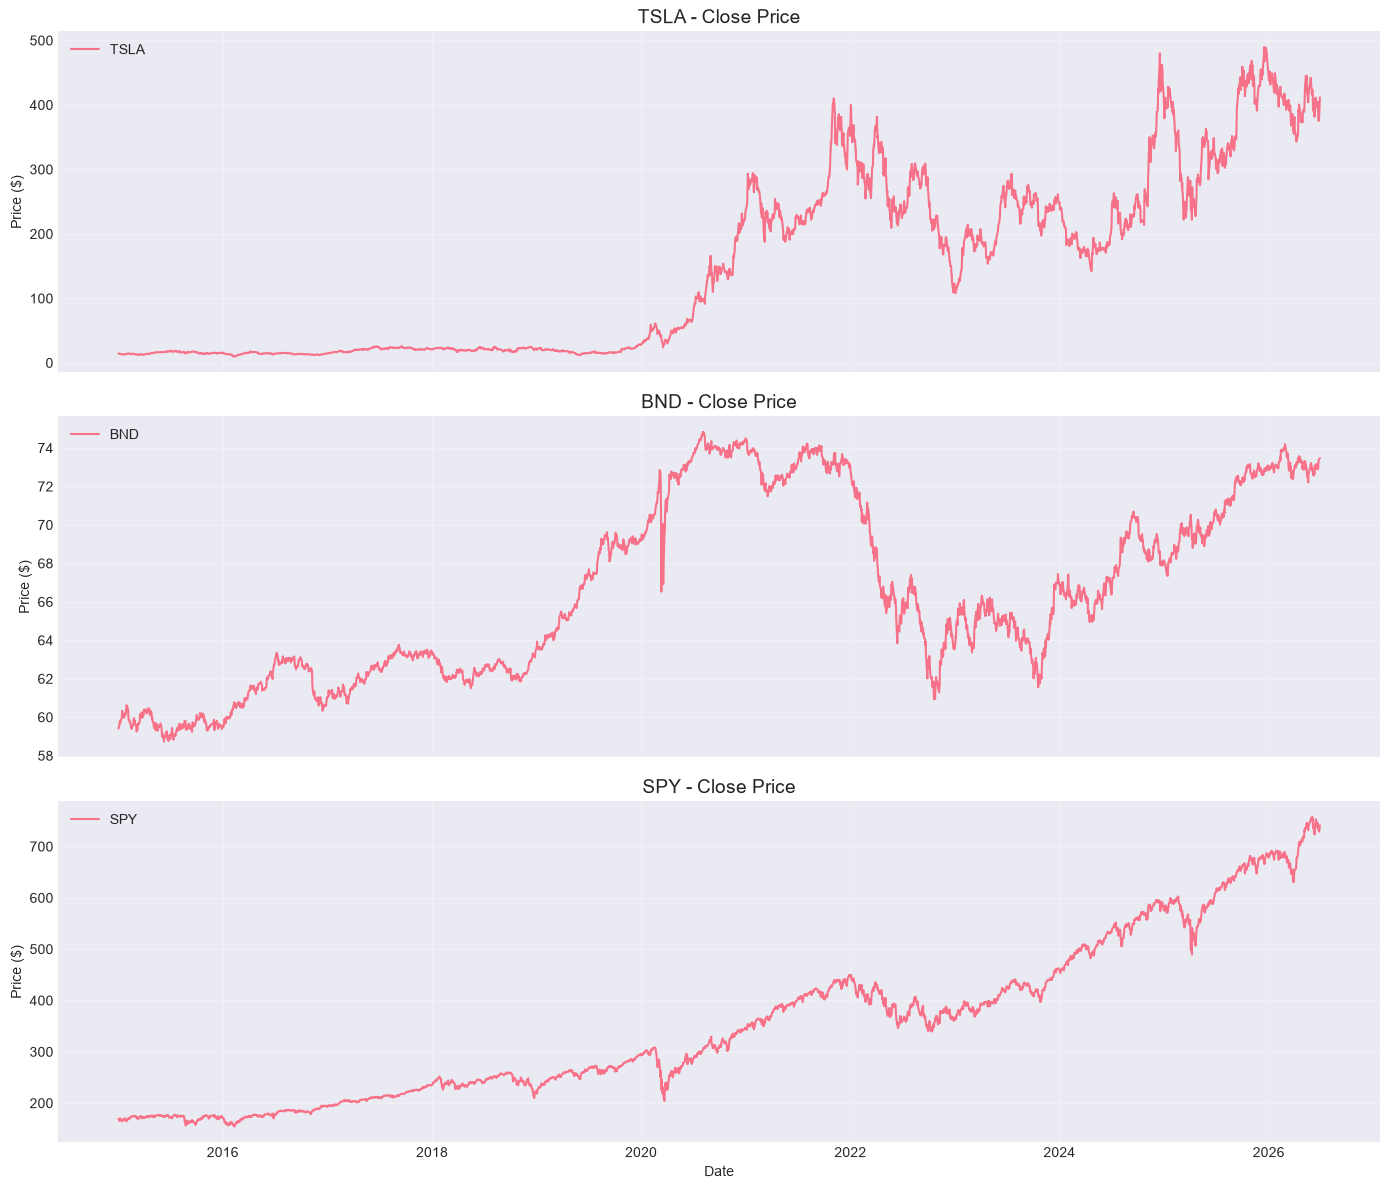

In [12]:
# Plot adjusted closing prices
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for idx, ticker in enumerate(assets.keys()):
    ax = axes[idx]
    ax.plot(adj_close_df.index, adj_close_df[ticker], label=ticker, linewidth=1.5)
    ax.set_title(f'{ticker} - Close Price', fontsize=14)
    ax.set_ylabel('Price ($)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../data/processed/close_prices.png', dpi=300, bbox_inches='tight')
plt.show()

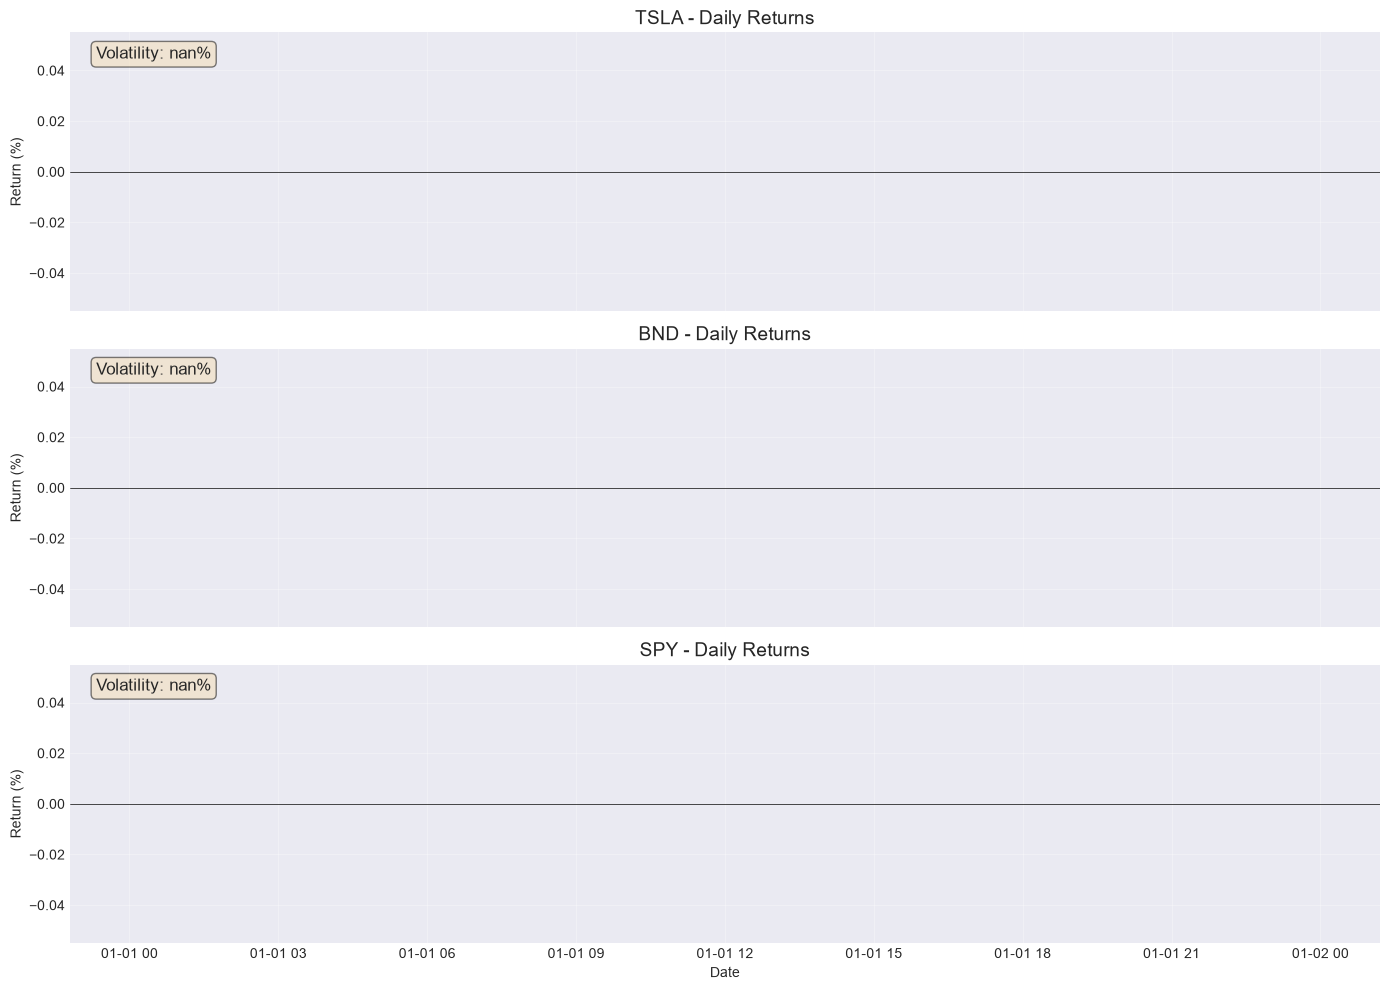

📊 Annualized Volatility:
  TSLA: nan%
  BND: nan%
  SPY: nan%


In [13]:
# Plot daily returns
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for idx, ticker in enumerate(assets.keys()):
    ax = axes[idx]
    ax.bar(returns_df.index, returns_df[ticker], alpha=0.5, width=2)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title(f'{ticker} - Daily Returns', fontsize=14)
    ax.set_ylabel('Return (%)')
    ax.grid(True, alpha=0.3)
    
    # Add volatility text
    vol = returns_df[ticker].std() * 100 * (252 ** 0.5)  # Annualized volatility
    ax.text(0.02, 0.95, f'Volatility: {vol:.1f}%', transform=ax.transAxes, fontsize=12, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../data/processed/daily_returns.png', dpi=300, bbox_inches='tight')
plt.show()

# Print volatility summary
print("📊 Annualized Volatility:")
for ticker in assets.keys():
    vol = returns_df[ticker].std() * (252 ** 0.5)
    print(f"  {ticker}: {vol*100:.2f}%")

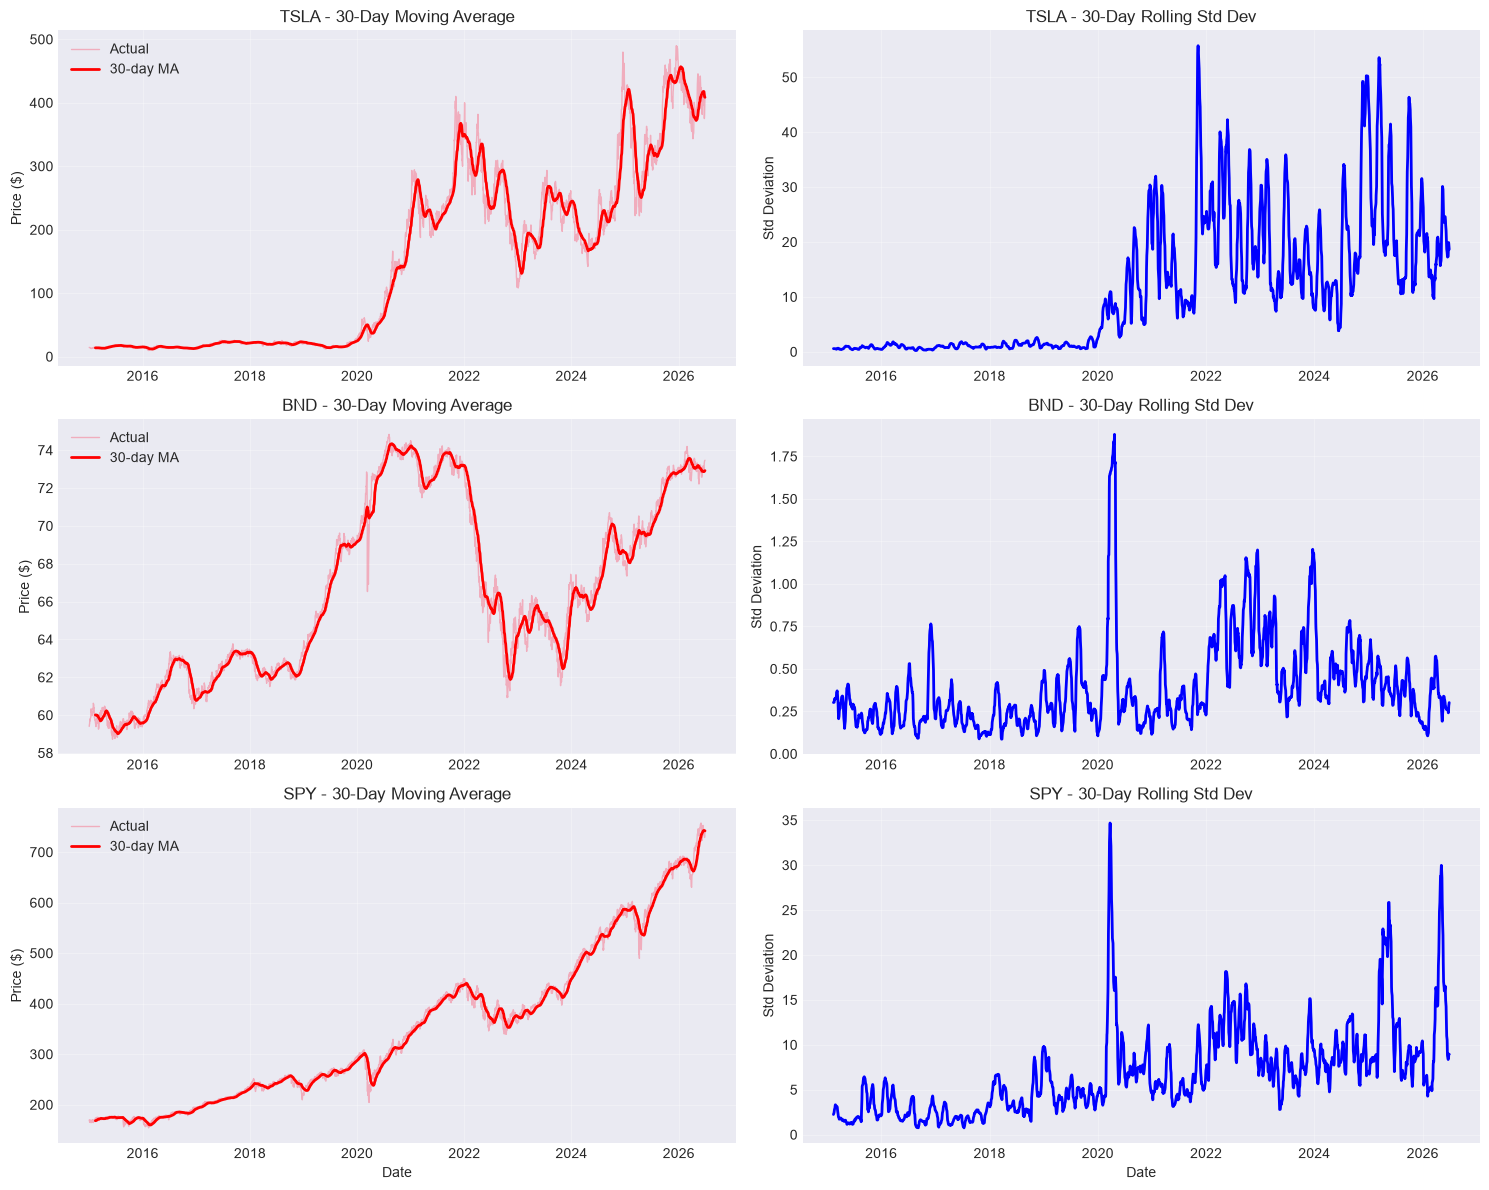

In [14]:
# Calculate rolling means and standard deviations
window = 30  # 30-day rolling window

# Create figure for rolling statistics
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for idx, ticker in enumerate(assets.keys()):
    # Rolling mean (30-day)
    ax1 = axes[idx, 0]
    ax1.plot(adj_close_df.index, adj_close_df[ticker], label='Actual', alpha=0.5, linewidth=1)
    ax1.plot(adj_close_df.index, adj_close_df[ticker].rolling(window=window).mean(), 
             label=f'{window}-day MA', color='red', linewidth=2)
    ax1.set_title(f'{ticker} - {window}-Day Moving Average')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Rolling standard deviation (volatility)
    ax2 = axes[idx, 1]
    ax2.plot(adj_close_df.index, adj_close_df[ticker].rolling(window=window).std(), 
             color='blue', linewidth=2)
    ax2.set_title(f'{ticker} - {window}-Day Rolling Std Dev')
    ax2.set_ylabel('Std Deviation')
    ax2.grid(True, alpha=0.3)

axes[2, 0].set_xlabel('Date')
axes[2, 1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../data/processed/rolling_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Check adj_close_df
print("🔍 Checking adj_close_df:")
print(f"Shape: {adj_close_df.shape}")
print(f"\nFirst 5 rows:")
print(adj_close_df.head())
print(f"\nLast 5 rows:")
print(adj_close_df.tail())
print(f"\nCheck if DataFrame is empty: {adj_close_df.empty}")
print(f"\nColumn names: {adj_close_df.columns.tolist()}")
print(f"\nData types:")
print(adj_close_df.dtypes)
print(f"\nAny NaN values?")
print(adj_close_df.isnull().sum())

🔍 Checking adj_close_df:
Shape: (8664, 3)

First 5 rows:
                 TSLA  BND  SPY
Date                           
2015-01-02  14.620667  NaN  NaN
2015-01-05  14.006000  NaN  NaN
2015-01-06  14.085333  NaN  NaN
2015-01-07  14.063333  NaN  NaN
2015-01-08  14.041333  NaN  NaN

Last 5 rows:
            TSLA  BND         SPY
Date                             
2026-06-23   NaN  NaN  733.580017
2026-06-24   NaN  NaN  733.239990
2026-06-25   NaN  NaN  734.299988
2026-06-26   NaN  NaN  728.989990
2026-06-29   NaN  NaN  741.000000

Check if DataFrame is empty: False

Column names: ['TSLA', 'BND', 'SPY']

Data types:
TSLA    float64
BND     float64
SPY     float64
dtype: object

Any NaN values?
TSLA    5776
BND     5776
SPY     5776
dtype: int64


In [16]:
# Rebuild adj_close_df with proper alignment - FIXED VERSION

# First, get the close prices as Series
close_series = {}

for ticker in assets.keys():
    # Get the data for this ticker from the original dictionary
    ticker_df = data[ticker]
    
    # Extract the 'Close' column
    if 'Close' in ticker_df.columns:
        close_prices = ticker_df['Close']
    elif 'Adj Close' in ticker_df.columns:
        close_prices = ticker_df['Adj Close']
    else:
        print(f"❌ No close price column found for {ticker}")
        continue
    
    # Store the Series
    close_series[ticker] = close_prices
    print(f"✅ Added {len(close_prices)} rows for {ticker}")

# Create DataFrame by concatenating with axis=1 (columns)
# This will align by index (date) automatically
adj_close_df = pd.concat(close_series, axis=1)

# Rename columns to just ticker names (remove the extra level)
adj_close_df.columns = adj_close_df.columns.droplevel(0)

print("\n" + "=" * 50)
print("✅ Adjusted Close DataFrame created with proper alignment!")
print(f"📊 Shape: {adj_close_df.shape}")
print(f"📅 Date range: {adj_close_df.index.min()} to {adj_close_df.index.max()}")
print("\nFirst 10 rows:")
print(adj_close_df.head(10))
print("\nLast 10 rows:")
print(adj_close_df.tail(10))

✅ Added 2888 rows for TSLA
✅ Added 2888 rows for BND
✅ Added 2888 rows for SPY

✅ Adjusted Close DataFrame created with proper alignment!
📊 Shape: (2888, 3)
📅 Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00

First 10 rows:
Ticker           TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405411  169.687836
2015-01-05  14.006000  59.577911  166.623367
2015-01-06  14.085333  59.750423  165.053894
2015-01-07  14.063333  59.786358  167.110672
2015-01-08  14.041333  59.692924  170.076111
2015-01-09  13.777333  59.793514  168.713150
2015-01-12  13.480667  59.872585  167.391510
2015-01-13  13.616667  59.930130  166.920715
2015-01-14  12.846000  60.066673  165.913025
2015-01-15  12.791333  60.332588  164.393112

Last 10 rows:
Ticker            TSLA        BND         SPY
Date                                         
2026-06-15  411.149994  73.056366  752.890381
2026-06-16  404.660004  73.166000  748.401978
2026-06-17  396.380005  72.8968

In [17]:
# Check for missing values
print("📊 Missing values per asset:")
print(adj_close_df.isnull().sum())
print(f"\nTotal missing: {adj_close_df.isnull().sum().sum()}")

# Check which dates are missing for each asset
print("\n📅 Date ranges for each asset:")
for ticker in assets.keys():
    non_null_dates = adj_close_df[ticker].dropna()
    if len(non_null_dates) > 0:
        print(f"  {ticker}: {non_null_dates.index.min()} to {non_null_dates.index.max()}")
        print(f"    Days with data: {len(non_null_dates)}")
    else:
        print(f"  {ticker}: No data!")

📊 Missing values per asset:
Ticker
TSLA    0
BND     0
SPY     0
dtype: int64

Total missing: 0

📅 Date ranges for each asset:
  TSLA: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
    Days with data: 2888
  BND: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
    Days with data: 2888
  SPY: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
    Days with data: 2888


In [18]:
# Clean the data using forward fill
adj_close_df_clean = adj_close_df.ffill()

print("📊 Data cleaning:")
print(f"Original shape: {adj_close_df.shape}")
print(f"After forward fill: {adj_close_df_clean.shape}")
print(f"\nMissing values after cleaning:")
print(adj_close_df_clean.isnull().sum())

# Check if any NaN remain (should be 0)
if adj_close_df_clean.isnull().sum().sum() == 0:
    print("✅ All missing values filled!")
else:
    print("⚠️ Some missing values remain - using backward fill as well")
    adj_close_df_clean = adj_close_df_clean.bfill()

print("\nFirst 10 rows after cleaning:")
print(adj_close_df_clean.head(10))

📊 Data cleaning:
Original shape: (2888, 3)
After forward fill: (2888, 3)

Missing values after cleaning:
Ticker
TSLA    0
BND     0
SPY     0
dtype: int64
✅ All missing values filled!

First 10 rows after cleaning:
Ticker           TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405411  169.687836
2015-01-05  14.006000  59.577911  166.623367
2015-01-06  14.085333  59.750423  165.053894
2015-01-07  14.063333  59.786358  167.110672
2015-01-08  14.041333  59.692924  170.076111
2015-01-09  13.777333  59.793514  168.713150
2015-01-12  13.480667  59.872585  167.391510
2015-01-13  13.616667  59.930130  166.920715
2015-01-14  12.846000  60.066673  165.913025
2015-01-15  12.791333  60.332588  164.393112


In [19]:
# Calculate daily returns
returns_df = adj_close_df_clean.pct_change().dropna()

print("📊 Returns DataFrame:")
print(f"Shape: {returns_df.shape}")
print(f"\nFirst 5 rows:")
print(returns_df.head())
print(f"\nSummary statistics:")
print(returns_df.describe())

# Check for any remaining NaN
print(f"\nAny NaN in returns? {returns_df.isnull().sum().sum()}")

📊 Returns DataFrame:
Shape: (2887, 3)

First 5 rows:
Ticker          TSLA       BND       SPY
Date                                    
2015-01-05 -0.042041  0.002904 -0.018059
2015-01-06  0.005664  0.002896 -0.009419
2015-01-07 -0.001562  0.000601  0.012461
2015-01-08 -0.001564 -0.001563  0.017745
2015-01-09 -0.018802  0.001685 -0.008014

Summary statistics:
Ticker         TSLA          BND          SPY
count   2887.000000  2887.000000  2887.000000
mean       0.001803     0.000079     0.000573
std        0.036018     0.003347     0.011121
min       -0.210628    -0.054385    -0.109424
25%       -0.016643    -0.001511    -0.003700
50%        0.001216     0.000134     0.000655
75%        0.019456     0.001773     0.005930
max        0.226900     0.042201     0.105019

Any NaN in returns? 0



📊 Asset Correlation Matrix:
Ticker      TSLA       BND       SPY
Ticker                              
TSLA    1.000000  0.059358  0.493534
BND     0.059358  1.000000  0.115705
SPY     0.493534  0.115705  1.000000


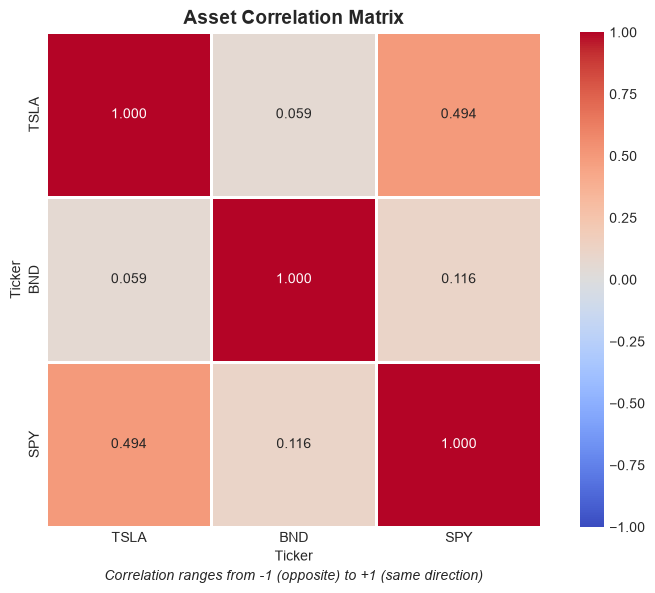


📊 CORRELATION INTERPRETATION
BND vs TSLA: 0.0594 (weak positive correlation)
BND vs SPY: 0.1157 (weak positive correlation)
SPY vs TSLA: 0.4935 (moderate positive correlation)


In [20]:
# Calculate correlation
correlation = returns_df.corr()

print("\n📊 Asset Correlation Matrix:")
print(correlation)

# Visualize correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.3f', 
            square=True, linewidths=1, vmin=-1, vmax=1)

plt.title('Asset Correlation Matrix', fontsize=14, fontweight='bold')
plt.text(0.5, -0.1, 
         'Correlation ranges from -1 (opposite) to +1 (same direction)',
         ha='center', va='center', transform=plt.gca().transAxes, 
         fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print interpretation
print("\n" + "=" * 60)
print("📊 CORRELATION INTERPRETATION")
print("=" * 60)

for asset1 in assets.keys():
    for asset2 in assets.keys():
        if asset1 < asset2:
            corr = correlation.loc[asset1, asset2]
            if abs(corr) < 0.2:
                strength = "weak"
            elif abs(corr) < 0.5:
                strength = "moderate"
            else:
                strength = "strong"
            
            direction = "positive" if corr > 0 else "negative"
            print(f"{asset1} vs {asset2}: {corr:.4f} ({strength} {direction} correlation)")

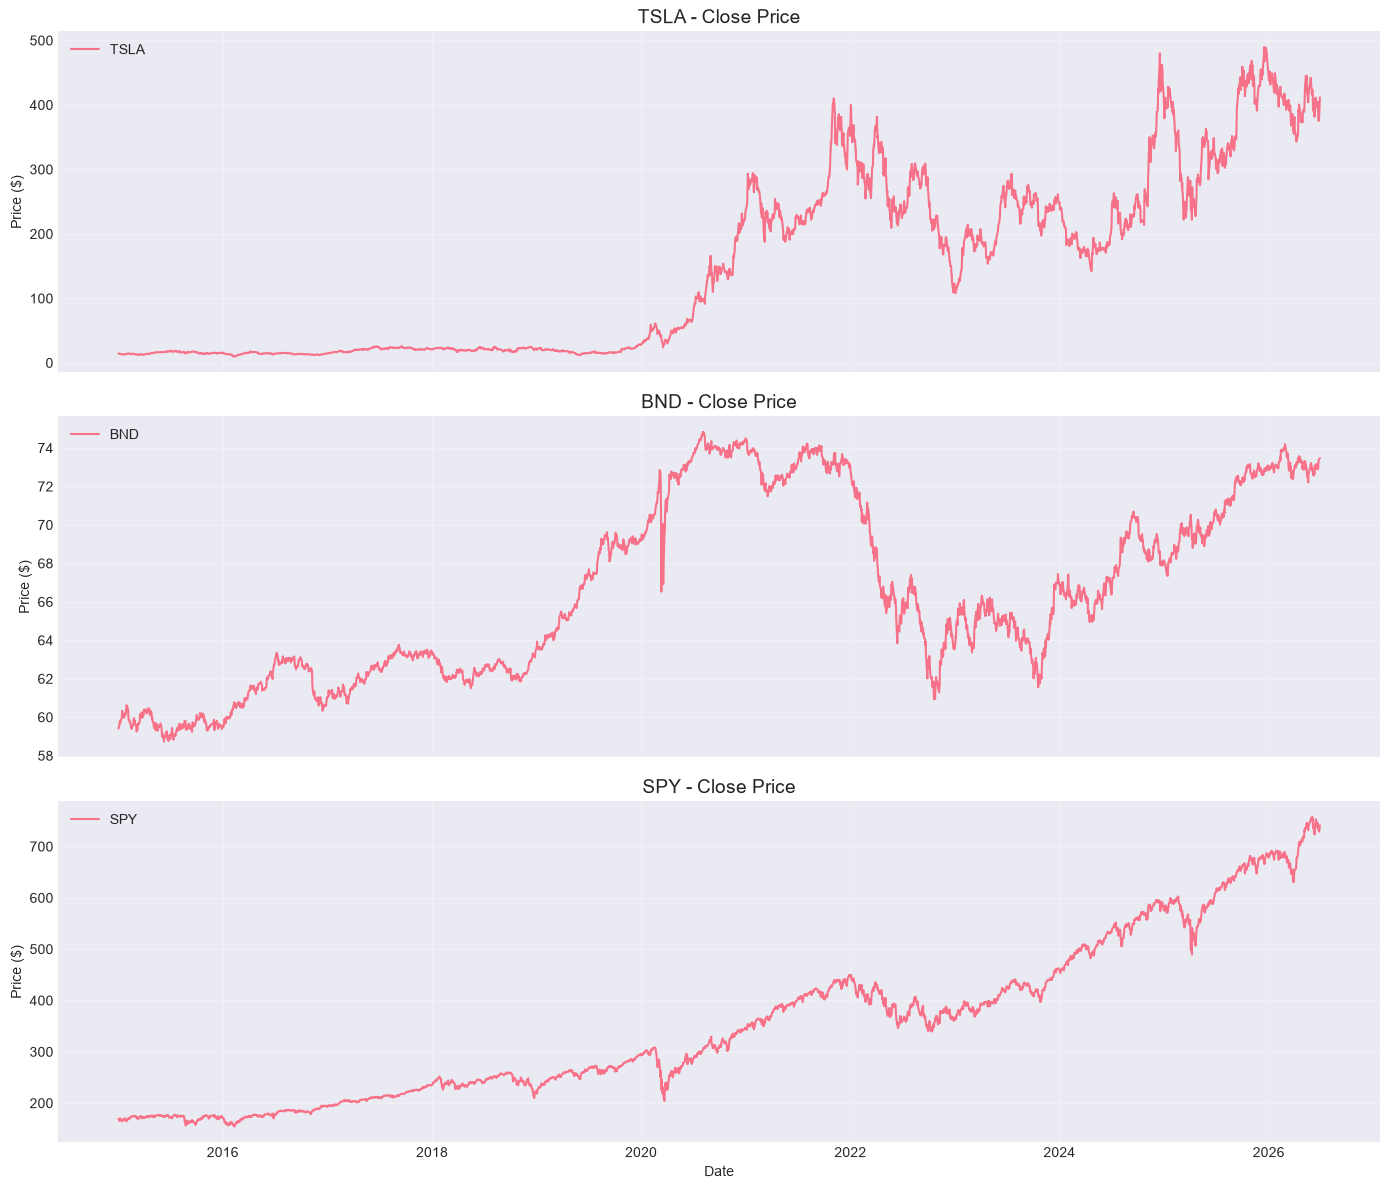

In [21]:
# Plot adjusted closing prices
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for idx, ticker in enumerate(assets.keys()):
    ax = axes[idx]
    ax.plot(adj_close_df_clean.index, adj_close_df_clean[ticker], label=ticker, linewidth=1.5)
    ax.set_title(f'{ticker} - Close Price', fontsize=14)
    ax.set_ylabel('Price ($)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../data/processed/close_prices.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Calculate comprehensive portfolio statistics
summary_stats = {}

for ticker in assets.keys():
    prices = adj_close_df_clean[ticker]
    returns = returns_df[ticker]
    
    # Calculate metrics
    start_price = prices.iloc[0]
    end_price = prices.iloc[-1]
    total_return = ((end_price / start_price) - 1) * 100
    annualized_return = returns.mean() * 252 * 100
    volatility = returns.std() * (252 ** 0.5) * 100
    
    # Calculate Sharpe Ratio (assuming risk-free rate of 1%)
    risk_free_rate = 0.01
    sharpe = (returns.mean() * 252 - risk_free_rate) / (returns.std() * (252 ** 0.5))
    
    # Calculate VaR at 95% confidence
    var_95 = np.percentile(returns, 5) * 100
    
    summary_stats[ticker] = {
        'Start Price ($)': f"{start_price:.2f}",
        'End Price ($)': f"{end_price:.2f}",
        'Total Return (%)': f"{total_return:.2f}",
        'Annualized Return (%)': f"{annualized_return:.2f}",
        'Volatility (Annual %)': f"{volatility:.2f}",
        'Sharpe Ratio': f"{sharpe:.3f}",
        'VaR 95% (%)': f"{var_95:.2f}"
    }

summary_df = pd.DataFrame(summary_stats).T

print("=" * 60)
print("📊 COMPREHENSIVE PORTFOLIO STATISTICS")
print("=" * 60)
print(summary_df)

📊 COMPREHENSIVE PORTFOLIO STATISTICS
     Start Price ($) End Price ($) Total Return (%) Annualized Return (%)  \
TSLA           14.62        411.84          2716.83                 45.42   
BND            59.41         73.47            23.67                  2.00   
SPY           169.69        741.00           336.68                 14.43   

     Volatility (Annual %) Sharpe Ratio VaR 95% (%)  
TSLA                 57.18        0.777       -5.17  
BND                   5.31        0.187       -0.48  
SPY                  17.65        0.761       -1.67  


In [24]:
# Save processed data as CSV
adj_close_df_clean.to_csv('../data/processed/adj_close_data_clean.csv')
returns_df.to_csv('../data/processed/returns_data_clean.csv')
summary_df.to_csv('../data/processed/assets_summary.csv')

print("✅ All data saved successfully as CSV!")
print(f"📁 adj_close_data_clean.csv: {adj_close_df_clean.shape}")
print(f"📁 returns_data_clean.csv: {returns_df.shape}")
print(f"📁 assets_summary.csv: {summary_df.shape}")

✅ All data saved successfully as CSV!
📁 adj_close_data_clean.csv: (2888, 3)
📁 returns_data_clean.csv: (2887, 3)
📁 assets_summary.csv: (3, 7)


In [25]:
# Verify saved files exist
import os

files_to_check = [
    '../data/processed/adj_close_data_clean.csv',
    '../data/processed/returns_data_clean.csv',
    '../data/processed/assets_summary.csv'
]

print("📁 Checking saved files:")
print("=" * 50)
for file in files_to_check:
    if os.path.exists(file):
        size = os.path.getsize(file)
        print(f"✅ {os.path.basename(file)} ({size:,} bytes)")
    else:
        print(f"❌ {os.path.basename(file)} not found")

📁 Checking saved files:
✅ adj_close_data_clean.csv (191,425 bytes)
✅ returns_data_clean.csv (221,188 bytes)
✅ assets_summary.csv (264 bytes)


In [26]:
print("=" * 70)
print("📊 TASK 1 COMPLETED: DATA PREPROCESSING AND EXPLORATION")
print("=" * 70)

print("\n✅ DATA EXTRACTION:")
print(f"   - Downloaded data for TSLA, BND, SPY")
print(f"   - Date range: {adj_close_df_clean.index.min()} to {adj_close_df_clean.index.max()}")
print(f"   - Total rows: {len(adj_close_df_clean)}")

print("\n✅ DATA CLEANING:")
print(f"   - Handled missing values using forward fill")
print(f"   - Final shape: {adj_close_df_clean.shape}")

print("\n✅ KEY METRICS:")
for ticker in assets.keys():
    start_price = adj_close_df_clean[ticker].iloc[0]
    end_price = adj_close_df_clean[ticker].iloc[-1]
    total_return = ((end_price / start_price) - 1) * 100
    vol = returns_df[ticker].std() * (252 ** 0.5) * 100
    sharpe = float(summary_df.loc[ticker, 'Sharpe Ratio'])
    print(f"   {ticker}:")
    print(f"      Start: ${start_price:.2f} → End: ${end_price:.2f}")
    print(f"      Return: {total_return:.2f}%")
    print(f"      Volatility: {vol:.2f}%")
    print(f"      Sharpe Ratio: {sharpe:.3f}")

print("\n✅ DATA SAVED:")
print(f"   - adj_close_data_clean.csv")
print(f"   - returns_data_clean.csv")
print(f"   - assets_summary.csv")

print("\n" + "=" * 70)
print("🎉 TASK 1 COMPLETE! Ready for Task 2")
print("=" * 70)

📊 TASK 1 COMPLETED: DATA PREPROCESSING AND EXPLORATION

✅ DATA EXTRACTION:
   - Downloaded data for TSLA, BND, SPY
   - Date range: 2015-01-02 00:00:00 to 2026-06-29 00:00:00
   - Total rows: 2888

✅ DATA CLEANING:
   - Handled missing values using forward fill
   - Final shape: (2888, 3)

✅ KEY METRICS:
   TSLA:
      Start: $14.62 → End: $411.84
      Return: 2716.83%
      Volatility: 57.18%
      Sharpe Ratio: 0.777
   BND:
      Start: $59.41 → End: $73.47
      Return: 23.67%
      Volatility: 5.31%
      Sharpe Ratio: 0.187
   SPY:
      Start: $169.69 → End: $741.00
      Return: 336.68%
      Volatility: 17.65%
      Sharpe Ratio: 0.761

✅ DATA SAVED:
   - adj_close_data_clean.csv
   - returns_data_clean.csv
   - assets_summary.csv

🎉 TASK 1 COMPLETE! Ready for Task 2
